# 🫀 ECG ResNet1D — v3.1 (variante MÁS COMPLEJA · CPU · modelo independiente)
## TFM · Módulo de ECG · Universidad de Salamanca

---

Variante **más potente** del ECG v3, manteniendo viabilidad en CPU (i5-1135G7, sin GPU).
Modelo **independiente** (sin fusión). Hereda todo lo del v3 y aumenta la capacidad.

## 🆙 Qué añade respecto al v3

| Mejora | Detalle |
|---|---|
| **ResNet1D más profundo y ancho** | `base_width` 32→**48**, **2 bloques residuales por etapa** (vs 1) → embedding 384 |
| **Mayor resolución temporal** | señal a **1250 muestras** (~125 Hz) en vez de 1000 |
| **Aumento de señal más rico** | ruido gaussiano + escalado de amplitud + **desplazamiento temporal** + **enmascarado de derivaciones** (lead masking) + deriva de línea base |
| **Ensemble (bagging) de K modelos** | la predicción de test es el **promedio de los K modelos** del K-fold |
| **Más presupuesto** | Optuna 10 trials · 24 épocas |

Se mantiene: **negativos derivados por exclusividad** (No Finding), **masking de NaN/−1 intacto**,
`pos_weight` dinámico, BCE/focal, **calibración isotónica**, metadatos de 16 dims, y salidas ricas
(matrices de confusión, ROC, PR, calibración, AUC por etiqueta).

## 🛡️ Masking (sin cambios)
NaN no cubierto → enmascarado · −1 → según `uncertainty_policy` · NaN cubierto por exclusividad → 0 observado.

## ⏱️ Coste (CPU): el backbone se entrena (sin atajo de embeddings). Modelo mayor + señal más larga +
más épocas → **≈ 3–4 h**. Usa `FAST_MODE=True` para una prueba; baja `ECG_LEN`/`OPTUNA_TRIALS`/`FINAL_EPOCHS` para acortar.


In [1]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try:
    import torch  # noqa: F401
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch",
                    "--index-url","https://download.pytorch.org/whl/cpu","-q"], check=True)
for pkg in ["optuna","scikit-learn","pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], check=True)
print("Dependencias instaladas.")


Dependencias instaladas.


In [2]:
# CELDA 2 · IMPORTS / SEMILLAS / DISPOSITIVO
import os, gc, json, time, copy, random, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import KFold
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.isotonic import IsotonicRegression
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING); warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
N_CORES=4; torch.set_num_threads(N_CORES)
os.environ["OMP_NUM_THREADS"]=str(N_CORES); os.environ["MKL_NUM_THREADS"]=str(N_CORES)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} · {DEVICE} · hilos {torch.get_num_threads()}")


c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.8.0+cpu · cpu · hilos 4


In [3]:
# CELDA 3 · RUTAS Y CONSTANTES (v3.1)
BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV_DIR/"train_clean.csv",CSV_DIR/"val_clean.csv",CSV_DIR/"test_clean.csv"
NPY=BASE/"data_npy"
ECG_TRAIN_NPY,ECG_VAL_NPY,ECG_TEST_NPY=NPY/"train"/"ecg_train.npy",NPY/"val"/"ecg_val.npy",NPY/"test"/"ecg_test.npy"
HADM_TRAIN_NPY,HADM_VAL_NPY,HADM_TEST_NPY=NPY/"train"/"hadm_id_train.npy",NPY/"val"/"hadm_id_val.npy",NPY/"test"/"hadm_id_test.npy"
OUTPUT_DIR=Path("outputs_ecg_resnet1d_v3_1").resolve(); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
PREP_DIR=OUTPUT_DIR/"prep"; PREP_DIR.mkdir(parents=True,exist_ok=True)
FIG_DIR=OUTPUT_DIR/"figuras"; FIG_DIR.mkdir(parents=True,exist_ok=True)
print("Salidas en:", OUTPUT_DIR)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY_LABELS=[l for l in LABELS if l!=NO_FINDING]; CORE_LABELS=["Cardiomegaly","Edema","Pleural Effusion"]
N_LEADS,ECG_RAW_LEN=12,5000
ECG_LEN=1250          # v3.1: mayor resolución temporal (~125 Hz)
DERIVE_NEGATIVES_FROM_EXCLUSIVITY=True

GENDER_MAP={0:0,1:1,"0":0,"1":1,"M":1,"F":0}
RACE_MAP={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADMISSION_MAP={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}
ADM_LOC_MAP={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}
RACE_ONEHOT=5
META_DIM=1+1+RACE_ONEHOT+len(ADMISSION_MAP)+len(ADM_LOC_MAP)+1   # 16

FAST_MODE=False
OPTUNA_TRIALS,TUNE_SUBSAMPLE,TUNE_EPOCHS,TUNE_PATIENCE=10,0.6,6,3
K_FOLDS,FINAL_EPOCHS,FINAL_PATIENCE=3,24,5
BATCH=64; BASE_WIDTH=48; BLOCKS_PER_STAGE=2     # v3.1: más ancho y profundo
if FAST_MODE:
    OPTUNA_TRIALS,TUNE_EPOCHS,K_FOLDS,FINAL_EPOCHS=3,3,2,6
print(f"v3.1 · ECG {N_LEADS}x{ECG_RAW_LEN}->{ECG_LEN} · base={BASE_WIDTH} bloques/etapa={BLOCKS_PER_STAGE} · trials={OPTUNA_TRIALS} K={K_FOLDS} ep={FINAL_EPOCHS}")


Salidas en: C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_ecg_resnet1d_v3_1
v3.1 · ECG 12x5000->1250 · base=48 bloques/etapa=2 · trials=10 K=3 ep=24


In [4]:
# CELDA 4 · CARGA Y ALINEACIÓN
def load_split(csv,ecg,hadm,name):
    df=pd.read_csv(csv,sep=";"); h=np.load(hadm,allow_pickle=True); h2i={int(x):i for i,x in enumerate(h)}
    df["_npy_idx"]=df["hadm_id"].map(lambda z:h2i.get(int(z),-1)); n0=len(df)
    df=df[df["_npy_idx"]>=0].reset_index(drop=True); a=np.load(ecg,mmap_mode="r")
    print(f"{name:5s}: CSV={n0:,} con ECG={len(df):,} · ECG {a.shape}"); return df,a
df_train,ecg_train=load_split(TRAIN_CSV,ECG_TRAIN_NPY,HADM_TRAIN_NPY,"train")
df_val,ecg_val=load_split(VAL_CSV,ECG_VAL_NPY,HADM_VAL_NPY,"val")
df_test,ecg_test=load_split(TEST_CSV,ECG_TEST_NPY,HADM_TEST_NPY,"test")


train: CSV=10,000 con ECG=10,000 · ECG (10000, 1, 5000, 12)
val  : CSV=750 con ECG=750 · ECG (750, 1, 5000, 12)
test : CSV=464 con ECG=464 · ECG (4640, 1, 5000, 12)


In [5]:
# CELDA 5 · OBJETIVOS (masking + negativos derivados)
def build_targets(df,uncertainty_policy="zeros",derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY,verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0; labels[raw==1]=1.0
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; n_dp=n_dn=n_c=0
    if derive:
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0; n_dp+=int(f.sum())
        n_c=int((nfp[:,None]&(raw[:,pc]==1)).sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0; n_dn=int(fn.sum())
    if verbose: print(f"   Neg. derivados patologías={n_dp:,} · No Finding={n_dn:,} · contradicciones={n_c:,}")
    return labels,mask
print("== Balance train =="); _y,_m=build_targets(df_train,"zeros",verbose=True)
for j,l in enumerate(LABELS):
    s=_m[:,j]==1; print(f"   {l:18s} pos={int((_y[s,j]==1).sum()):5d} neg={int((_y[s,j]==0).sum()):5d}")


== Balance train ==
   Neg. derivados patologías=6,091 · No Finding=7,691 · contradicciones=0
   Atelectasis        pos= 2867 neg= 2052
   Cardiomegaly       pos= 3346 neg= 2495
   Edema              pos= 2067 neg= 3735
   Lung Opacity       pos= 3108 neg= 1733
   No Finding         pos= 1368 neg= 7691
   Pleural Effusion   pos= 3618 neg= 3194


In [6]:
# CELDA 6 · METADATOS (16 dims)
AGE_MIN,AGE_MAX=float(df_train["age"].min()),float(df_train["age"].max())
HRS_MIN,HRS_MAX=float(df_train["hours_adm_to_cxr"].min()),float(df_train["hours_adm_to_cxr"].max())
def build_metadata(df):
    N=len(df); M=np.zeros((N,META_DIM),np.float32)
    for i,(_,r) in enumerate(df.iterrows()):
        o=0
        M[i,o]=(float(r.get("age",AGE_MIN))-AGE_MIN)/(AGE_MAX-AGE_MIN+1e-8); o+=1
        M[i,o]=float(GENDER_MAP.get(r.get("gender",0),0)); o+=1
        M[i,o+RACE_MAP.get(str(r.get("race","UNKNOWN")).upper(),0)]=1.0; o+=RACE_ONEHOT
        M[i,o+ADMISSION_MAP.get(str(r.get("admission_type","EMERGENCY")).upper(),1)]=1.0; o+=len(ADMISSION_MAP)
        M[i,o+ADM_LOC_MAP.get(str(r.get("admission_location","EMERGENCY_ROOM")).upper(),0)]=1.0; o+=len(ADM_LOC_MAP)
        M[i,o]=(float(r.get("hours_adm_to_cxr",HRS_MIN))-HRS_MIN)/(HRS_MAX-HRS_MIN+1e-8); o+=1
    return M
meta_train,meta_val,meta_test=build_metadata(df_train),build_metadata(df_val),build_metadata(df_test)
print(f"Metadatos {meta_train.shape} {meta_val.shape} {meta_test.shape}")


Metadatos (10000, 16) (750, 16) (464, 16)


In [7]:
# CELDA 7 · PREPROCESADO ECG (CORREGIDO: alinear señal con _npy_idx)
def preprocess_ecg(df, ecg, name):
    cache = PREP_DIR / f"ecg_{name}_{ECG_LEN}.npy"
    if cache.exists():
        X = np.load(cache)
        if len(X) == len(df):
            print(f"   {name}: caché {X.shape}"); return X
        print(f"   {name}: caché obsoleta ({len(X)} != {len(df)}), recalculando")
    idx = df["_npy_idx"].to_numpy()
    N = len(idx); factor = ECG_RAW_LEN // ECG_LEN
    X = np.empty((N, N_LEADS, ECG_LEN), np.float32)
    for k in tqdm(range(N), desc=f"prep {name}", leave=False):
        a = np.asarray(ecg[int(idx[k])], np.float32).reshape(ECG_RAW_LEN, N_LEADS).T
        a = a[:, :factor*ECG_LEN].reshape(N_LEADS, ECG_LEN, factor).mean(2)
        mu = a.mean(1, keepdims=True); sd = a.std(1, keepdims=True)
        X[k] = (a - mu) / (sd + 1e-6)
    cache.parent.mkdir(parents=True, exist_ok=True); np.save(cache, X)
    print(f"   {name}: calculado {X.shape}"); return X

print("Preprocesando ECG (alineado con _npy_idx)...")
X_train = preprocess_ecg(df_train, ecg_train, "train")
X_val   = preprocess_ecg(df_val,   ecg_val,   "val")
X_test  = preprocess_ecg(df_test,  ecg_test,  "test")
print(f"X_train={X_train.shape} X_val={X_val.shape} X_test={X_test.shape}")

Preprocesando ECG (alineado con _npy_idx)...
   train: caché (10000, 12, 1250)
   val: caché (750, 12, 1250)
   test: caché (464, 12, 1250)
X_train=(10000, 12, 1250) X_val=(750, 12, 1250) X_test=(464, 12, 1250)


In [8]:
# CELDA 8 · MODELO ResNet1D MÁS PROFUNDO (2 bloques/etapa, base 48)
class BasicBlock1d(nn.Module):
    def __init__(s,cin,cout,stride=1,k=7,dropout=0.0):
        super().__init__(); pad=k//2
        s.c1=nn.Conv1d(cin,cout,k,stride,pad,bias=False); s.b1=nn.BatchNorm1d(cout)
        s.c2=nn.Conv1d(cout,cout,k,1,pad,bias=False); s.b2=nn.BatchNorm1d(cout)
        s.drop=nn.Dropout(dropout); s.down=None
        if stride!=1 or cin!=cout: s.down=nn.Sequential(nn.Conv1d(cin,cout,1,stride,bias=False),nn.BatchNorm1d(cout))
    def forward(s,x):
        idt=x if s.down is None else s.down(x)
        o=F.relu(s.b1(s.c1(x)),inplace=True); o=s.drop(o); o=s.b2(s.c2(o)); return F.relu(o+idt,inplace=True)

def make_stage(cin,cout,stride,nblocks,dropout):
    layers=[BasicBlock1d(cin,cout,stride,dropout=dropout)]
    for _ in range(nblocks-1): layers.append(BasicBlock1d(cout,cout,1,dropout=dropout))
    return nn.Sequential(*layers)

class LabelCorrelation(nn.Module):
    def __init__(s,n=N_LABELS):
        super().__init__(); s.lin=nn.Linear(n,n,bias=False); nn.init.eye_(s.lin.weight)
        s.lin.weight.data*=0.1; s.norm=nn.LayerNorm(n)
    def forward(s,x): return s.norm(x+s.lin(x))

class ECGResNet1D(nn.Module):
    def __init__(s,base=BASE_WIDTH,blocks=BLOCKS_PER_STAGE,dropout=0.3,use_corr=True,use_meta=True):
        super().__init__(); s.use_meta=use_meta
        s.stem=nn.Sequential(nn.Conv1d(N_LEADS,base,15,2,7,bias=False),nn.BatchNorm1d(base),
                             nn.ReLU(inplace=True),nn.MaxPool1d(3,2,1))
        s.layer1=make_stage(base,base,1,blocks,dropout)
        s.layer2=make_stage(base,base*2,2,blocks,dropout)
        s.layer3=make_stage(base*2,base*4,2,blocks,dropout)
        s.layer4=make_stage(base*4,base*8,2,blocks,dropout)
        s.pool=nn.AdaptiveAvgPool1d(1); emb=base*8
        s.sig_proj=nn.Sequential(nn.Linear(emb,256),nn.BatchNorm1d(256),nn.ReLU(inplace=True))
        if use_meta:
            s.meta=nn.Sequential(nn.Linear(META_DIM,64),nn.BatchNorm1d(64),nn.ReLU(inplace=True)); fused=256+64
        else: s.meta=None; fused=256
        s.head=nn.Sequential(nn.Dropout(dropout),nn.Linear(fused,128),nn.BatchNorm1d(128),
                             nn.ReLU(inplace=True),nn.Dropout(dropout*0.5),nn.Linear(128,N_LABELS))
        s.corr=LabelCorrelation() if use_corr else None
        for m in s.modules():
            if isinstance(m,(nn.Conv1d,nn.Linear)):
                nn.init.kaiming_normal_(m.weight,nonlinearity="relu")
                if getattr(m,"bias",None) is not None: nn.init.zeros_(m.bias)
    def forward(s,x,meta=None):
        z=s.stem(x); z=s.layer1(z); z=s.layer2(z); z=s.layer3(z); z=s.layer4(z)
        z=s.pool(z).flatten(1); z=s.sig_proj(z)
        if s.use_meta and meta is not None: z=torch.cat([z,s.meta(meta)],1)
        lo=s.head(z); return s.corr(lo) if s.corr is not None else lo
print("ECGResNet1D v3.1 params:", sum(p.numel() for p in ECGResNet1D().parameters()))


ECGResNet1D v3.1 params: 5061206


In [9]:
# CELDA 9 · PÉRDIDA / pos_weight / MÉTRICAS
class MaskedLoss(nn.Module):
    def __init__(s,pos_weight,loss_type="bce",focal_gamma=2.0):
        super().__init__(); s.register_buffer("pw",pos_weight); s.lt=loss_type; s.g=focal_gamma
    def forward(s,logits,labels,mask):
        pw=s.pw.to(logits.device)
        if s.lt=="focal":
            bce=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw,reduction="none")
            p=torch.sigmoid(logits); pt=labels*p+(1-labels)*(1-p); loss=((1-pt)**s.g)*bce
        else: loss=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw,reduction="none")
        loss=loss*mask; return loss.sum()/mask.sum().clamp(min=1e-8)
def dynamic_pos_weights(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return torch.tensor(w,dtype=torch.float32)
def sample_weights_by_rarity(y,m):
    combo=[tuple(int(v) for v in (y[i]*m[i]).astype(int)) for i in range(len(y))]
    c=Counter(combo); return torch.tensor([1.0/c[k] for k in combo],dtype=torch.double)
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        thr=thresholds.get(l,0.5); pred=(yp>=thr).astype(float)
        if npos>=2 and nneg>=2: auc=roc_auc_score(yt,yp); ap=average_precision_score(yt,yp)
        else: auc=ap=float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),
                "sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),"n_pos":npos,"n_neg":nneg,
                "thr":thr,"TP":tp,"TN":tn,"FP":fp,"FN":fn}
    def mac(g):
        v=[res[l]["AUC"] for l in g if not np.isnan(res[l]["AUC"])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"]=mac(CORE_LABELS); res["macro_AUC_path"]=mac(PATHOLOGY_LABELS); return res
def best_thresholds_by_f1(probs,labels,mask,grid=None):
    if grid is None: grid=np.linspace(0.05,0.95,37)
    thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
print("Pérdida y métricas listas.")


Pérdida y métricas listas.


In [10]:
# CELDA 10 · DATASET con AUMENTO RICO + ENTRENAMIENTO
def augment_signal(x):
    # x: (12, L). Aumento de señal más rico para ECG.
    x = x + np.random.normal(0, 0.025, x.shape).astype(np.float32)         # ruido gaussiano
    x = x * np.float32(np.random.uniform(0.85, 1.15))                       # escalado de amplitud
    sh = np.random.randint(-int(0.05*x.shape[1]), int(0.05*x.shape[1])+1)   # desplazamiento temporal
    if sh != 0: x = np.roll(x, sh, axis=1)
    if np.random.rand() < 0.3:                                              # lead masking
        lead = np.random.randint(0, x.shape[0]); x = x.copy(); x[lead] = 0.0
    if np.random.rand() < 0.3:                                              # deriva de línea base
        t = np.linspace(0, 2*np.pi*np.random.uniform(0.5,2.0), x.shape[1], dtype=np.float32)
        x = x + (0.1*np.sin(t))[None, :].astype(np.float32)
    return x

class ECGDataset(Dataset):
    def __init__(s,X,meta,y,m,augment=False): s.X,s.meta,s.y,s.m,s.aug=X,meta,y,m,augment
    def __len__(s): return len(s.X)
    def __getitem__(s,i):
        x=s.X[i]
        if s.aug: x=augment_signal(x)
        return (torch.from_numpy(np.ascontiguousarray(x)),torch.from_numpy(s.meta[i]),
                torch.from_numpy(s.y[i]),torch.from_numpy(s.m[i]))

@torch.no_grad()
def predict(model,X,meta,batch=256):
    model.eval(); out=[]
    for i in range(0,len(X),batch):
        xb=torch.from_numpy(np.ascontiguousarray(X[i:i+batch])).to(DEVICE); mb=torch.from_numpy(meta[i:i+batch]).to(DEVICE)
        out.append(torch.sigmoid(model(xb,mb)).cpu().numpy())
    return np.concatenate(out,0)

def train_model(X_tr,meta_tr,y_tr,m_tr,X_va,meta_va,y_va,m_va,cfg,n_epochs,patience):
    crit=MaskedLoss(dynamic_pos_weights(y_tr,m_tr),cfg.get("loss_type","bce"),cfg.get("focal_gamma",2.0)).to(DEVICE)
    model=ECGResNet1D(BASE_WIDTH,BLOCKS_PER_STAGE,cfg["dropout"],cfg["use_corr"],cfg["use_meta"]).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=cfg["lr"],weight_decay=cfg["weight_decay"])
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=n_epochs,eta_min=1e-7)
    ds=ECGDataset(X_tr,meta_tr,y_tr,m_tr,augment=cfg.get("use_augment",True))
    if cfg.get("use_sampler",False):
        sw=sample_weights_by_rarity(y_tr,m_tr)
        loader=DataLoader(ds,batch_size=BATCH,sampler=WeightedRandomSampler(sw,len(sw),True),num_workers=0,drop_last=True)
    else:
        loader=DataLoader(ds,batch_size=BATCH,shuffle=True,num_workers=0,drop_last=True)
    best,bs,wait=-1.0,None,0; hist={"train_loss":[],"val_auc":[]}
    for ep in range(n_epochs):
        model.train(); tl,nb=0.0,0
        for xb,mb,yb,msb in loader:
            xb,mb,yb,msb=xb.to(DEVICE),mb.to(DEVICE),yb.to(DEVICE),msb.to(DEVICE)
            opt.zero_grad(); loss=crit(model(xb,mb),yb,msb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step(); tl+=loss.item(); nb+=1
        sched.step()
        sc=multilabel_metrics(predict(model,X_va,meta_va),y_va,m_va)["macro_AUC_path"]
        hist["train_loss"].append(tl/max(nb,1)); hist["val_auc"].append(sc)
        if not np.isnan(sc) and sc>best+1e-4: best,bs,wait=sc,copy.deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=patience: break
    if bs is not None: model.load_state_dict(bs)
    return model,best,hist
print("Dataset con aumento rico y entrenamiento listos.")


Dataset con aumento rico y entrenamiento listos.


In [11]:
# CELDA 11 · OPTUNA (split interno 85/15)
rng=np.random.RandomState(SEED); perm=rng.permutation(len(df_train)); cut=int(0.85*len(perm))
tune_tr_idx,tune_va_idx=perm[:cut],perm[cut:]
def objective(trial):
    cfg={"lr":trial.suggest_float("lr",1e-4,3e-3,log=True),
         "weight_decay":trial.suggest_float("weight_decay",1e-5,1e-3,log=True),
         "dropout":trial.suggest_float("dropout",0.1,0.5),
         "use_corr":trial.suggest_categorical("use_corr",[True,False]),
         "use_meta":trial.suggest_categorical("use_meta",[True,False]),
         "use_sampler":trial.suggest_categorical("use_sampler",[True,False]),
         "use_augment":trial.suggest_categorical("use_augment",[True,False]),
         "loss_type":trial.suggest_categorical("loss_type",["bce","focal"]),
         "focal_gamma":trial.suggest_categorical("focal_gamma",[1.5,2.0]),
         "policy":trial.suggest_categorical("policy",["zeros","ones"])}
    y_all,m_all=build_targets(df_train,cfg["policy"])
    sub=rng.choice(tune_tr_idx,size=int(len(tune_tr_idx)*TUNE_SUBSAMPLE),replace=False)
    model,_,_=train_model(X_train[sub],meta_train[sub],y_all[sub],m_all[sub],
                          X_train[tune_va_idx],meta_train[tune_va_idx],y_all[tune_va_idx],m_all[tune_va_idx],
                          cfg,TUNE_EPOCHS,TUNE_PATIENCE)
    sc=multilabel_metrics(predict(model,X_train[tune_va_idx],meta_train[tune_va_idx]),
                          y_all[tune_va_idx],m_all[tune_va_idx])["macro_AUC_path"]
    del model; gc.collect(); return sc
t0=time.time(); study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective,n_trials=OPTUNA_TRIALS,show_progress_bar=True); BEST=study.best_params
print(f"\nOptuna {(time.time()-t0)/60:.1f} min · mejor macroAUC_path={study.best_value:.4f}")
for k,v in BEST.items(): print(f"   {k:14s} = {v}")


Best trial: 9. Best value: 0.616534: 100%|██████████| 10/10 [4:00:17<00:00, 1441.76s/it] 


Optuna 240.3 min · mejor macroAUC_path=0.6165
   lr             = 0.0005284222249942597
   weight_decay   = 0.0009360540102485373
   dropout        = 0.19682210860460017
   use_corr       = False
   use_meta       = False
   use_sampler    = False
   use_augment    = True
   loss_type      = focal
   focal_gamma    = 1.5
   policy         = ones


In [12]:
# CELDA 12 · K-FOLD: estimación CV + ENSEMBLE (bagging) + OOF de train (para stacking)
cfg=dict(BEST)
y_train,m_train=build_targets(df_train,cfg["policy"])
y_val,m_val=build_targets(df_val,cfg["policy"]); y_test,m_test=build_targets(df_test,cfg["policy"])
kf=KFold(K_FOLDS,shuffle=True,random_state=SEED)
# oof_train: cada muestra de train la predice el modelo del fold que NO la entrenó -> sin fuga (válido para el meta-modelo)
fold_rows=[]; oof_train=np.zeros((len(df_train),N_LABELS),np.float32)
acc_val=np.zeros((len(df_val),N_LABELS),np.float32); acc_test=np.zeros((len(df_test),N_LABELS),np.float32); histories=[]
t0=time.time()
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    tk=time.time()
    model,_,hist=train_model(X_train[tr],meta_train[tr],y_train[tr],m_train[tr],
                             X_train[va],meta_train[va],y_train[va],m_train[va],cfg,FINAL_EPOCHS,FINAL_PATIENCE)
    pva=predict(model,X_train[va],meta_train[va]); oof_train[va]=pva    # <- OOF sin fuga
    mm=multilabel_metrics(pva,y_train[va],m_train[va]); fold_rows.append(mm)
    acc_val+=predict(model,X_val,meta_val); acc_test+=predict(model,X_test,meta_test); histories.append(hist)
    print(f"Fold {k+1}/{K_FOLDS}: macroAUC_path={mm['macro_AUC_path']:.4f} core={mm['macro_AUC_core']:.4f} ({(time.time()-tk)/60:.1f} min)")
    del model; gc.collect()
val_pred_raw=acc_val/K_FOLDS; test_pred_raw=acc_test/K_FOLDS
cv_core=[f["macro_AUC_core"] for f in fold_rows]; cv_path=[f["macro_AUC_path"] for f in fold_rows]
print(f"\nCV {K_FOLDS}-fold ({(time.time()-t0)/60:.1f} min) · core={np.nanmean(cv_core):.4f}±{np.nanstd(cv_core):.4f} · path={np.nanmean(cv_path):.4f}±{np.nanstd(cv_path):.4f}")

Fold 1/3: macroAUC_path=0.6189 core=0.6318 (63.8 min)
Fold 2/3: macroAUC_path=0.6061 core=0.6167 (22.3 min)
Fold 3/3: macroAUC_path=0.6132 core=0.6337 (25.5 min)

CV 3-fold (111.6 min) · core=0.6274±0.0076 · path=0.6128±0.0052


In [13]:
# CELDA 13 · CALIBRACIÓN (val) del ensemble + umbrales
calibrators={}
for j,l in enumerate(LABELS):
    s=m_val[:,j]==1; yt=y_val[s,j]; yp=val_pred_raw[s,j]
    if len(np.unique(yt))<2: calibrators[l]=None; continue
    iso=IsotonicRegression(out_of_bounds="clip"); iso.fit(yp,yt); calibrators[l]=iso
def apply_cal(p):
    o=p.copy()
    for j,l in enumerate(LABELS):
        if calibrators[l] is not None: o[:,j]=calibrators[l].predict(p[:,j])
    return o
val_pred=apply_cal(val_pred_raw); test_pred=apply_cal(test_pred_raw)
thr_val=best_thresholds_by_f1(val_pred,y_val,m_val)
torch.save({"config":cfg,"thresholds":thr_val,"k_folds":K_FOLDS}, OUTPUT_DIR/"config_v3_1.pt")
print("Ensemble calibrado · umbrales fijados.")


Ensemble calibrado · umbrales fijados.


In [14]:
# CELDA 13b · EXPORTAR OOF/val/test PARA EL STACKING (formato idéntico al CXR)
# - oof_train : probabilidades OUT-OF-FOLD del K-fold (sin fuga) -> para ENTRENAR el meta-modelo.
# - val/test  : promedio del ensemble K-fold (crudas y calibradas con la isotónica de val).
# El stacking ya solo tiene que LEER estos 3 CSV (no re-entrena el ECG).
def save_predictions(df, raw, cal, name):
    cols={"hadm_id": df["hadm_id"].to_numpy()}
    for j,l in enumerate(LABELS):
        key=l.replace(" ","_")
        cols[f"ecg_{key}"]=raw[:,j]; cols[f"ecg_{key}_cal"]=cal[:,j]
    out=pd.DataFrame(cols); path=OUTPUT_DIR/f"ecg_pred_{name}.csv"; out.to_csv(path,index=False)
    print(f"   guardado {path}  ({out.shape[0]} filas, {out.shape[1]} cols)"); return out

oof_cal=apply_cal(oof_train)
save_predictions(df_train, oof_train,     oof_cal,   "oof_train")
save_predictions(df_val,   val_pred_raw,  val_pred,  "val")
save_predictions(df_test,  test_pred_raw, test_pred, "test")
print("OOF/val/test del ECG exportados -> los carga directamente el stacking.")

   guardado C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_ecg_resnet1d_v3_1\ecg_pred_oof_train.csv  (10000 filas, 13 cols)
   guardado C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_ecg_resnet1d_v3_1\ecg_pred_val.csv  (750 filas, 13 cols)
   guardado C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_ecg_resnet1d_v3_1\ecg_pred_test.csv  (464 filas, 13 cols)
OOF/val/test del ECG exportados -> los carga directamente el stacking.


In [15]:
# CELDA 14 · EVALUACIÓN EN TEST + TABLA
M=multilabel_metrics(test_pred,y_test,m_test,thresholds=thr_val); rows=[]
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'Sens':>6} {'Spec':>6} {'N+':>5} {'N-':>5}")
print("-"*74)
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{l:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['sens']:6.3f} {m['spec']:6.3f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label":l,**{k:m[k] for k in ["AUC","AP","F1","sens","spec","n_pos","n_neg","TP","TN","FP","FN","thr"]}})
print("-"*74); print(f"{'MACRO core':18s} {M['macro_AUC_core']:.4f}  ·  MACRO patol. {M['macro_AUC_path']:.4f}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_per_label_v3_1.csv",index=False)
summary={"version":"ECG v3.1 ResNet1D profundo + aumento rico + ensemble","best_config":BEST,"ecg_len":ECG_LEN,
         "cv_macro_core":[float(np.nanmean(cv_core)),float(np.nanstd(cv_core))],
         "cv_macro_path":[float(np.nanmean(cv_path)),float(np.nanstd(cv_path))],
         "test_macro_core":M["macro_AUC_core"],"test_macro_path":M["macro_AUC_path"],
         "test_per_label":{l:M[l] for l in LABELS}}
with open(OUTPUT_DIR/"summary_v3_1.json","w",encoding="utf-8") as f: json.dump(summary,f,indent=2,default=str,ensure_ascii=False)
print("Guardados metrics_per_label_v3_1.csv y summary_v3_1.json")


Etiqueta               AUC      AP      F1   Sens   Spec    N+    N-
--------------------------------------------------------------------------
Atelectasis         0.6334  0.7592  0.8170  1.000  0.000   163    73
Cardiomegaly        0.6760  0.7014  0.7792  0.957  0.261   164   111
Edema               0.6285  0.5532  0.6400  0.860  0.301   121   143
Lung Opacity        0.6346  0.7231  0.7867  0.993  0.050   143    80
No Finding          0.6261  0.2572  0.3314  0.406  0.794    69   349
Pleural Effusion    0.6149  0.6402  0.7027  0.862  0.272   181   147
--------------------------------------------------------------------------
MACRO core         0.6398  ·  MACRO patol. 0.6375
Guardados metrics_per_label_v3_1.csv y summary_v3_1.json


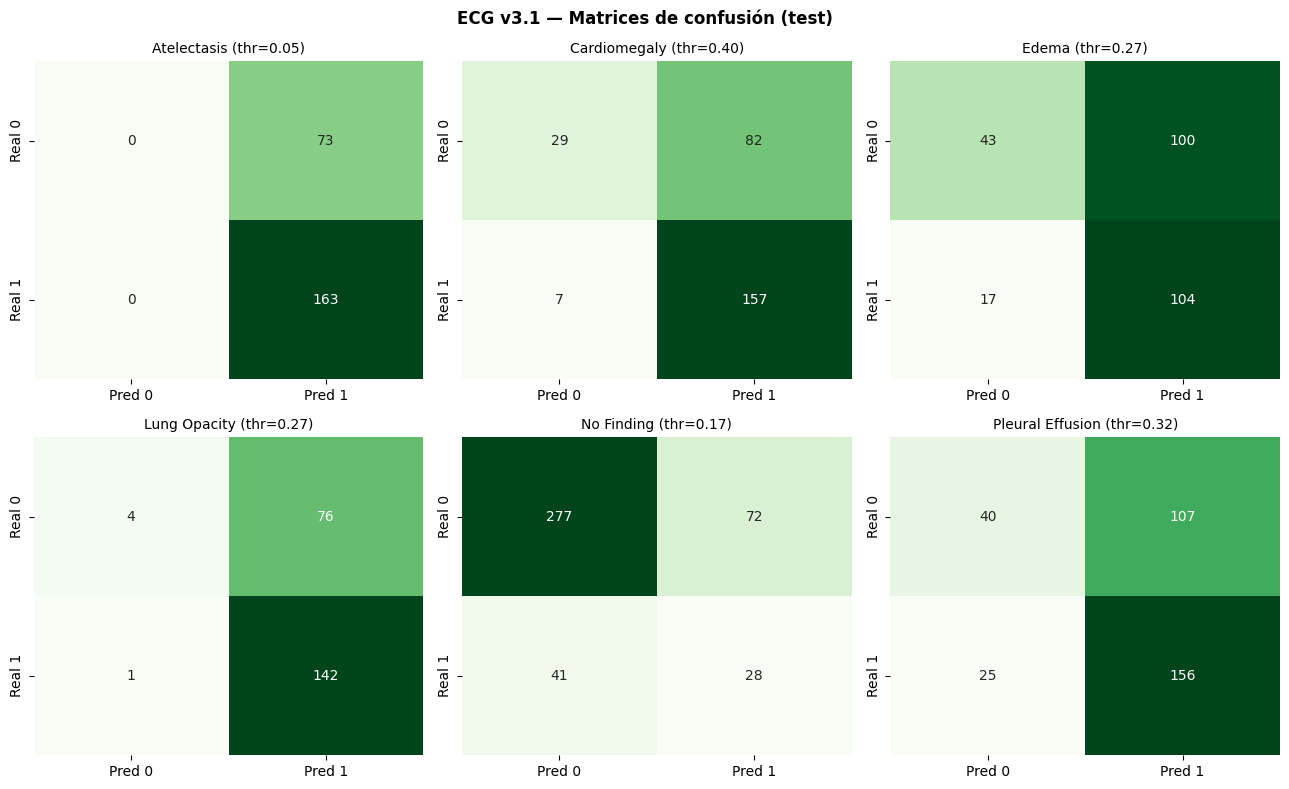

Matrices de confusión guardadas.


In [16]:
# CELDA 15 · MATRICES DE CONFUSIÓN
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle("ECG v3.1 — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    cm=confusion_matrix(yt,yp,labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",cbar=False,ax=ax,
                xticklabels=["Pred 0","Pred 1"],yticklabels=["Real 0","Real 1"])
    ax.set_title(f"{l} (thr={thr_val.get(l,0.5):.2f})",fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_matrices_v3_1.png",dpi=150,bbox_inches="tight"); plt.show()
print("Matrices de confusión guardadas.")


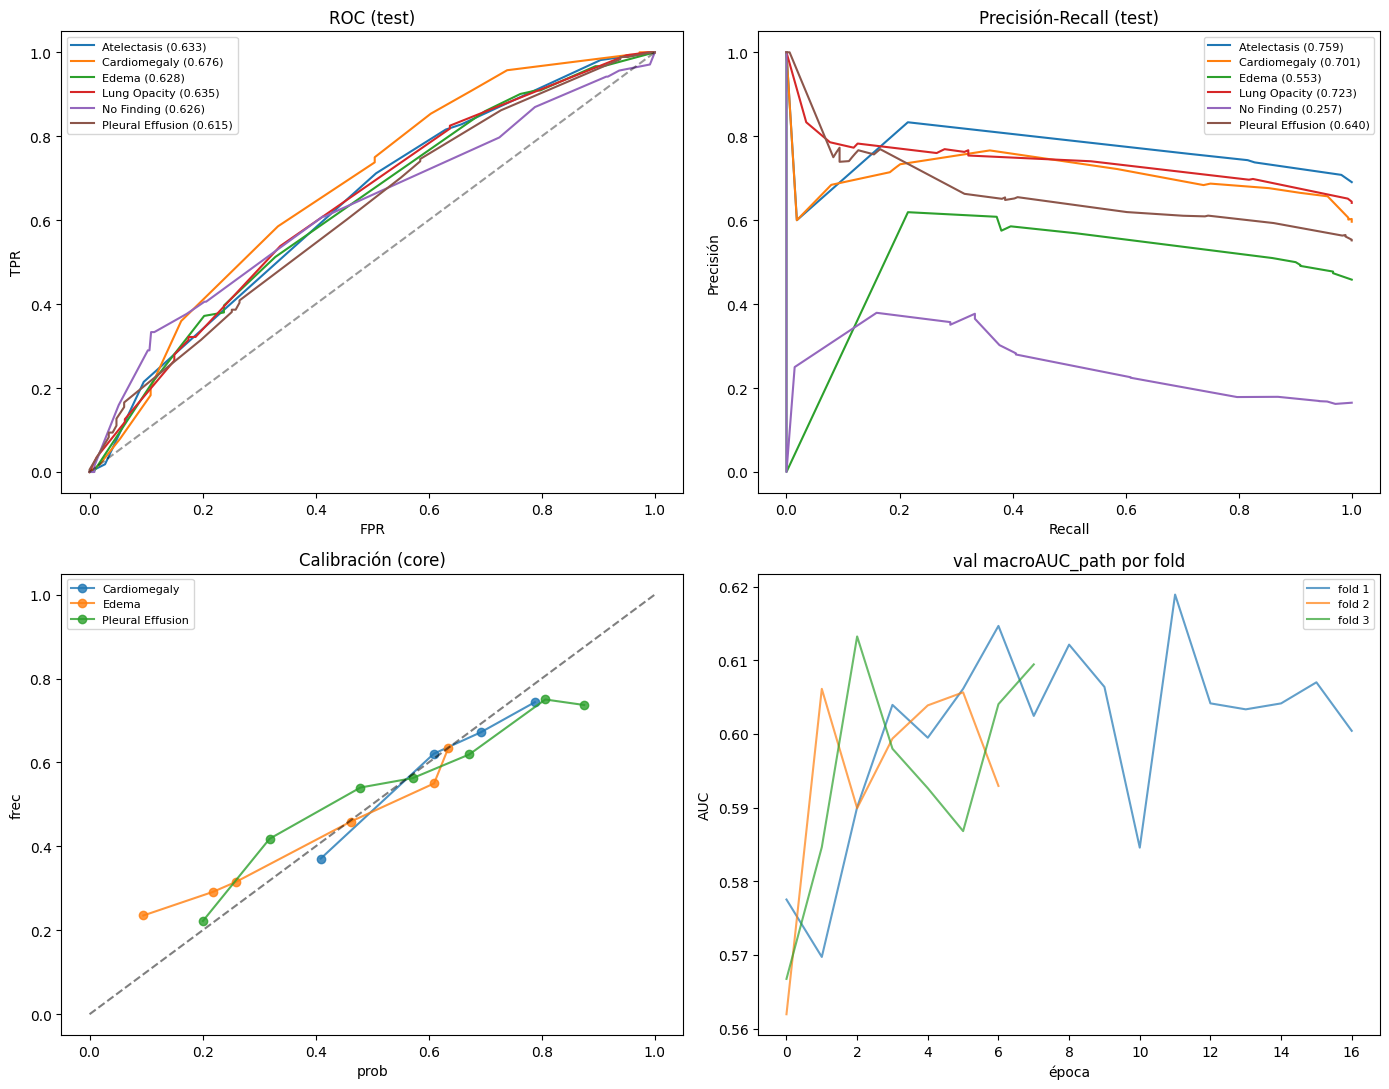

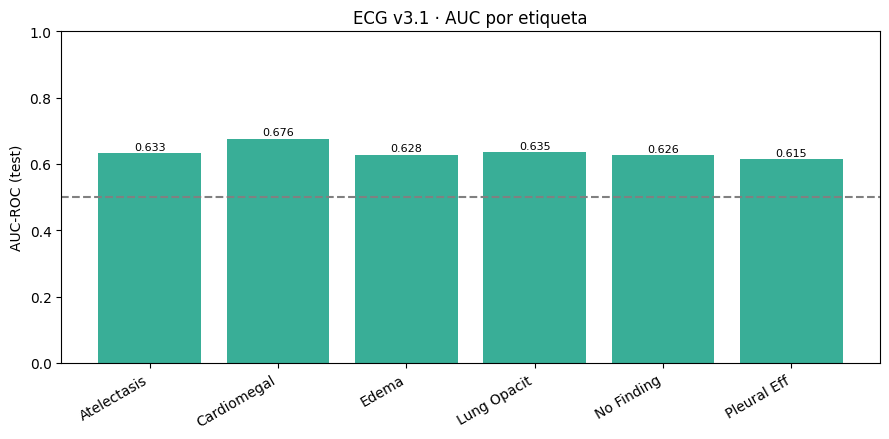

Figuras guardadas en C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_ecg_resnet1d_v3_1\figuras


In [17]:
# CELDA 16 · CURVAS ROC / PR / CALIBRACIÓN / ENTRENAMIENTO + AUC
fig,axes=plt.subplots(2,2,figsize=(14,11))
ax=axes[0,0]
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    if len(np.unique(yt))<2: continue
    fpr,tpr,_=roc_curve(yt,yp); ax.plot(fpr,tpr,label=f"{l} ({M[l]['AUC']:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=0.4); ax.set_title("ROC (test)"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8)
ax=axes[0,1]
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    if len(np.unique(yt))<2: continue
    pr,rc,_=precision_recall_curve(yt,yp); ax.plot(rc,pr,label=f"{l} ({M[l]['AP']:.3f})")
ax.set_title("Precisión-Recall (test)"); ax.set_xlabel("Recall"); ax.set_ylabel("Precisión"); ax.legend(fontsize=8)
ax=axes[1,0]
for l in CORE_LABELS:
    j=LABELS.index(l); s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    bins=np.linspace(0,1,9); idx=np.digitize(yp,bins)-1; xs,ys=[],[]
    for b in range(len(bins)-1):
        mb=idx==b
        if mb.sum()>5: xs.append(yp[mb].mean()); ys.append(yt[mb].mean())
    ax.plot(xs,ys,"o-",label=l,alpha=0.8)
ax.plot([0,1],[0,1],"k--",alpha=0.5); ax.set_title("Calibración (core)"); ax.set_xlabel("prob"); ax.set_ylabel("frec"); ax.legend(fontsize=8)
ax=axes[1,1]
for k,h in enumerate(histories): ax.plot(h["val_auc"],alpha=0.7,label=f"fold {k+1}")
ax.set_title("val macroAUC_path por fold"); ax.set_xlabel("época"); ax.set_ylabel("AUC"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/"curvas_v3_1.png",dpi=150,bbox_inches="tight"); plt.show()
fig2,ax=plt.subplots(figsize=(9,4.5)); aucs=[M[l]["AUC"] for l in LABELS]
ax.bar(range(N_LABELS),[0 if np.isnan(a) else a for a in aucs],
       color=["#c0392b" if (np.isnan(a) or a<0.55) else "#16a085" for a in aucs],alpha=0.85)
ax.axhline(0.5,color="gray",ls="--"); ax.set_xticks(range(N_LABELS)); ax.set_xticklabels([l[:11] for l in LABELS],rotation=30,ha="right")
ax.set_ylim(0,1); ax.set_ylabel("AUC-ROC (test)"); ax.set_title("ECG v3.1 · AUC por etiqueta")
for i,a in enumerate(aucs):
    if not np.isnan(a): ax.text(i,a+0.01,f"{a:.3f}",ha="center",fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/"auc_por_etiqueta_v3_1.png",dpi=150,bbox_inches="tight"); plt.show()
print("Figuras guardadas en", FIG_DIR)


In [18]:
# CELDA 17 · EQUIDAD POR SUBGRUPO
dft=df_test.reset_index(drop=True)
for col,lab in [("gender","GÉNERO"),("race","RAZA"),("admission_type","INGRESO")]:
    if col not in dft.columns: continue
    print(f"\n-- AUC macro (patologías) por {lab} --")
    for v in sorted(dft[col].dropna().unique(),key=str):
        idx=dft.index[dft[col]==v].to_numpy()
        if len(idx)<15: print(f"   {str(v):22s} n={len(idx):4d} (insuficiente)"); continue
        mm=multilabel_metrics(test_pred[idx],y_test[idx],m_test[idx])
        print(f"   {str(v):22s} n={len(idx):4d}  macroAUC_path={mm['macro_AUC_path']:.4f}")
print("\nEquidad completada.")



-- AUC macro (patologías) por GÉNERO --
   0                      n= 184  macroAUC_path=0.6433
   1                      n= 280  macroAUC_path=0.6309

-- AUC macro (patologías) por RAZA --
   ASIAN                  n=  15  macroAUC_path=0.8777
   BLACK                  n=  58  macroAUC_path=0.5328
   HISPANIC_LATINO        n=  21  macroAUC_path=0.5164
   OTHER_KNOWN            n=   3 (insuficiente)
   UNKNOWN                n=  52  macroAUC_path=0.6605
   WHITE                  n= 315  macroAUC_path=0.6542

-- AUC macro (patologías) por INGRESO --
   EMERGENCY              n= 322  macroAUC_path=0.6606
   OBSERVATION            n=  66  macroAUC_path=0.5527
   SCHEDULED              n=  34  macroAUC_path=0.5895
   URGENT                 n=  42  macroAUC_path=0.5980

Equidad completada.


---
## ✅ Resumen — ECG v3.1
Variante más compleja del v3: **ResNet1D más profundo y ancho** (2 bloques/etapa, base 48), **señal a mayor resolución** (1250), **aumento de señal más rico** (ruido, escalado, desplazamiento, lead masking, deriva de base) y **ensemble (bagging) de K modelos**. Mantiene negativos derivados, masking intacto, calibración y salidas ricas. Coste CPU ≈ 3–4 h (usa `FAST_MODE` para prueba).
